<a href="https://colab.research.google.com/github/aditi980/ANN-Datapredictor/blob/main/ANN_Data_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap pyngrok streamlit -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU detected: {gpus[0].name} — training will be FAST!")
else:
    print("No GPU found. Go to Runtime → hange Runtime Type → T4 GPU")

print(f"TensorFlow version: {tf.__version__}")

 GPU detected: /physical_device:GPU:0 — training will be FAST!
TensorFlow version: 2.20.0


In [ ]:
import os
import sys
import json
import pickle
import logging
import warnings
from datetime import datetime
from pathlib import Path

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight #to balance imbalanced clSSES

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow import keras

In [ ]:
from tensorflow.keras import layers, regularizers

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
plt.style.use('dark_background')

In [ ]:
COLORS = {
    'churn':    '#f85149',  # Red — danger/warning color for churn
    'no_churn': '#39d353',  # Green — safe/good color for no churn
    'accent':   '#00d4ff',  # Cyan — highlight/accent color
    'neutral':  '#7d8590',  # Grey — muted/secondary information
}

In [ ]:
pd.set_option('display.max_columns', 50)

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
print(" All libraries imported successfully!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   TensorFlow: {tf.__version__}")

 All libraries imported successfully!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   TensorFlow: 2.20.0


In [ ]:
df_raw = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df_raw.columns = df_raw.columns.str.strip() #removes white spaces from colummn names

In [ ]:
print(f"Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Shape : 7,043 rows × 21 columns


In [ ]:
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Memory: 6.82 MB


In [ ]:
print("\n First 5 rows:")
df_raw.head()


 First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [ ]:
column_guide = {
    'customerID':       ('ID',         'Unique customer identifier — NOT a feature, will be dropped'),
    'gender':           ('Demo',       'Customer gender: Male or Female'),
    'SeniorCitizen':    ('Demo',       'Is the customer 65+? 1=Yes, 0=No (already numeric)'),
    'Partner':          ('Demo',       'Does the customer have a spouse/partner? Yes/No'),
    'Dependents':       ('Demo',       'Does the customer have children/dependents? Yes/No'),
    'tenure':           ('Service',    'How many months has the customer been with the company?'),
    'PhoneService':     ('Service',    'Does the customer have a phone line? Yes/No'),
    'MultipleLines':    ('Service',    'Multiple phone lines? Yes/No/No phone service'),
    'InternetService':  ('Service',    'Internet type: DSL / Fiber optic / No'),
    'OnlineSecurity':   ('AddOn',      'Online security package? Yes/No/No internet service'),
    'OnlineBackup':     ('AddOn',      'Online backup package? Yes/No/No internet service'),
    'DeviceProtection': ('AddOn',      'Device insurance? Yes/No/No internet service'),
    'TechSupport':      ('AddOn',      'Technical support package? Yes/No/No internet service'),
    'StreamingTV':      ('AddOn',      'TV streaming service? Yes/No/No internet service'),
    'StreamingMovies':  ('AddOn',      'Movie streaming service? Yes/No/No internet service'),
    'Contract':         ('Billing',    'Contract length: Month-to-month / One year / Two year'),
    'PaperlessBilling': ('Billing',    'Does the customer use paperless billing? Yes/No'),
    'PaymentMethod':    ('Billing',    'How the customer pays: Electronic check/Mailed check/Bank transfer/Credit card'),
    'MonthlyCharges':   ('Financial',  'Amount charged to customer each month (USD)'),
    'TotalCharges':     ('Financial',  'Total amount charged over customer lifetime (USD)'),
    'Churn':            ('🎯 TARGET',  '⭐ Did the customer leave? Yes=Churned, No=Stayed ← THIS IS WHAT WE PREDICT'),
}

In [ ]:
guide_df = pd.DataFrame(
    [(col, cat, desc) for col, (cat, desc) in column_guide.items()],
    columns=['Column', 'Category', 'Description']
)

In [ ]:
print("COLUMN REFERENCE GUIDE")
display(guide_df)

COLUMN REFERENCE GUIDE


,Column,Category,Description
0,customerID,ID,"Unique customer identifier — NOT a feature, wi..."
1,gender,Demo,Customer gender: Male or Female
2,SeniorCitizen,Demo,"Is the customer 65+? 1=Yes, 0=No (already nume..."
3,Partner,Demo,Does the customer have a spouse/partner? Yes/No
4,Dependents,Demo,Does the customer have children/dependents? Ye...
5,tenure,Service,How many months has the customer been with the...
6,PhoneService,Service,Does the customer have a phone line? Yes/No
7,MultipleLines,Service,Multiple phone lines? Yes/No/No phone service
8,InternetService,Service,Internet type: DSL / Fiber optic / No
9,OnlineSecurity,AddOn,Online security package? Yes/No/No internet se...


In [ ]:
print("DATA TYPES")
print(df_raw.dtypes)

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
df_check = df_raw.copy()

In [ ]:
df_check['TotalCharges'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')

In [ ]:
missing = df_check.isnull().sum()

In [ ]:
missing_pct = (missing / len(df_check) * 100).round(2)

In [ ]:
missing_pct = (missing / len(df_check) * 100).round(2)
missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
missing_report = missing_data[missing_data['Missing Count'] > 0]

if len(missing_report) > 0:
    print("Columns with missing values:")
    display(missing_report)
else:
    print("No missing values found!")

Columns with missing values:


,Missing Count,Missing Percentage
TotalCharges,11,0.1600


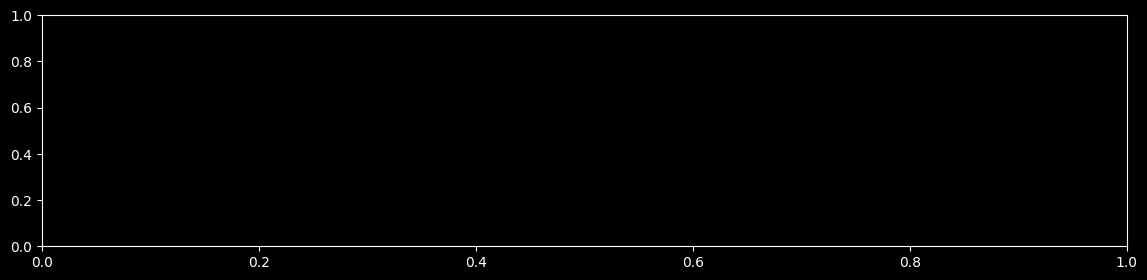

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))

In [ ]:
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

sns.heatmap(
    df_check.isnull().T,  # .T transposes (flips rows↔cols) so features are on Y-axis
    cbar=False,
    cmap='Reds',
    yticklabels=True,
    ax=ax
)
ax.set_title('Missing Values Heatmap (Red = Missing)', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
churn_counts = df_raw['Churn'].value_counts()

In [ ]:
churn_rate = (df_raw['Churn'] == 'Yes').mean() * 100

In [ ]:
print(f"CLASS DISTRIBUTION")
print(f"   No Churn (stayed) : {churn_counts['No']:,} customers ({100-churn_rate:.1f}%)")
print(f"   Churn    (left)   : {churn_counts['Yes']:,} customers ({churn_rate:.1f}%)")
print(f"\n Class Imbalance Ratio: {churn_counts['No']/churn_counts['Yes']:.1f}:1")
print(f"   This means for every churned customer, there are {churn_counts['No']/churn_counts['Yes']:.1f} who stayed.")
print(f"   We'll use class weights to handle this imbalance during training.")


CLASS DISTRIBUTION
   No Churn (stayed) : 5,174 customers (73.5%)
   Churn    (left)   : 1,869 customers (26.5%)

 Class Imbalance Ratio: 2.8:1
   This means for every churned customer, there are 2.8 who stayed.
   We'll use class weights to handle this imbalance during training.


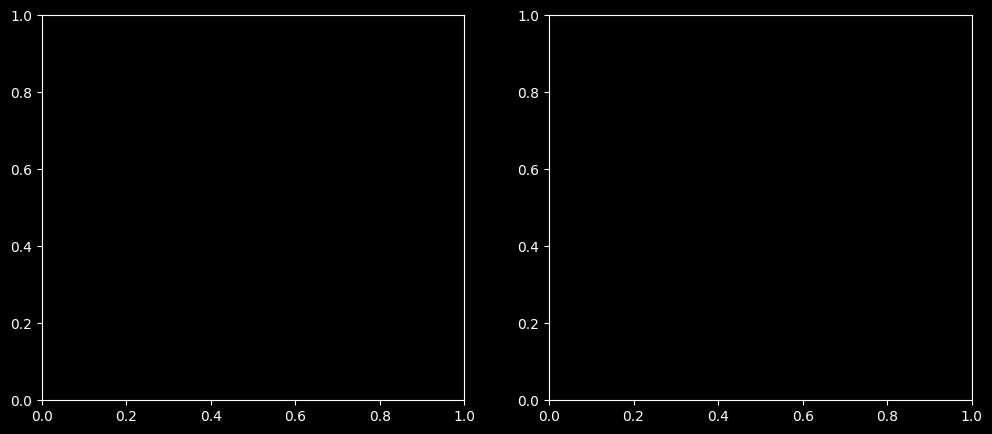

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

In [ ]:
bars = ax1.bar(
    ['No Churn', 'Churn'],
    churn_counts.values,
    color=[COLORS['no_churn'], COLORS['churn']],
    edgecolor='white', linewidth=0.5, width=0.5
)

In [ ]:
for bar, val in zip(bars, churn_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

In [ ]:
ax1.set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Customers')

Text(4.444444444444466, 0.5, 'Number of Customers')

In [ ]:
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

wedges, texts, autotexts = ax2.pie(
    churn_counts.values,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    colors=[COLORS['no_churn'], COLORS['churn']],
    startangle=90,
    explode=(0, 0.08),
    shadow=True
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax2.set_title('Churn Proportion', fontsize=13, fontweight='bold')

fig.suptitle('Target Variable (Churn) Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
df_eda = df_raw.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda.dropna(subset=['TotalCharges'], inplace=True)

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
print("DESCRIPTIVE STATISTICS (Numeric Features)")
display(df_eda[numeric_cols].describe().round(2))

DESCRIPTIVE STATISTICS (Numeric Features)


,tenure,MonthlyCharges,TotalCharges
count,7032.0000,7032.0000,7032.0000
mean,32.4200,64.8000,2283.3000
std,24.5500,30.0900,2266.7700
min,1.0000,18.2500,18.8000
25%,9.0000,35.5900,401.4500
50%,29.0000,70.3500,1397.4800
75%,55.0000,89.8600,3794.7400
max,72.0000,118.7500,8684.8000


In [ ]:
print("\n STATISTICS BY CHURN STATUS")
display(df_eda.groupby('Churn')[numeric_cols].mean().round(2))


 STATISTICS BY CHURN STATUS


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.6500,61.3100,2555.3400
Yes,17.9800,74.4400,1531.8000


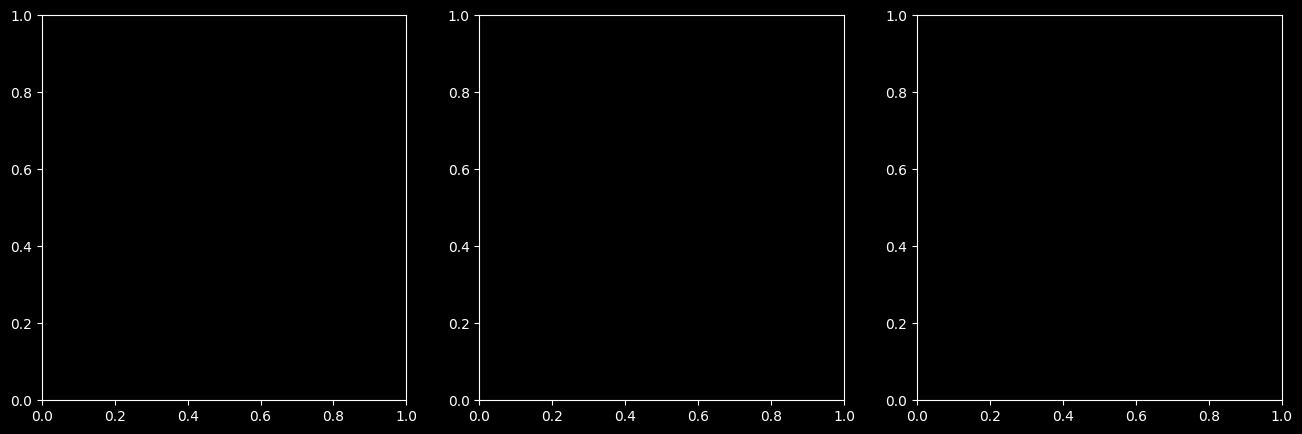

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

In [ ]:
for ax, col in zip(axes, numeric_cols):

    for churn_val, color, label in [
        ('Yes', COLORS['churn'],    'Churned'),
        ('No',  COLORS['no_churn'], 'Stayed')
    ]:
        data = df_eda[df_eda['Churn'] == churn_val][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()


In [ ]:
fig.suptitle('Numeric Feature Distributions by Churn Status',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_numeric_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHTS:")
print("  Tenure:  Churners tend to be NEW customers (short tenure) — loyalty builds over time")
print("  MonthlyCharges: Churners pay MORE per month — likely getting less value for money")
print("  TotalCharges: Churners have lower totals — because they leave early (low tenure)")

<Figure size 640x480 with 0 Axes>


 KEY INSIGHTS:
  Tenure:  Churners tend to be NEW customers (short tenure) — loyalty builds over time
  MonthlyCharges: Churners pay MORE per month — likely getting less value for money
  TotalCharges: Churners have lower totals — because they leave early (low tenure)


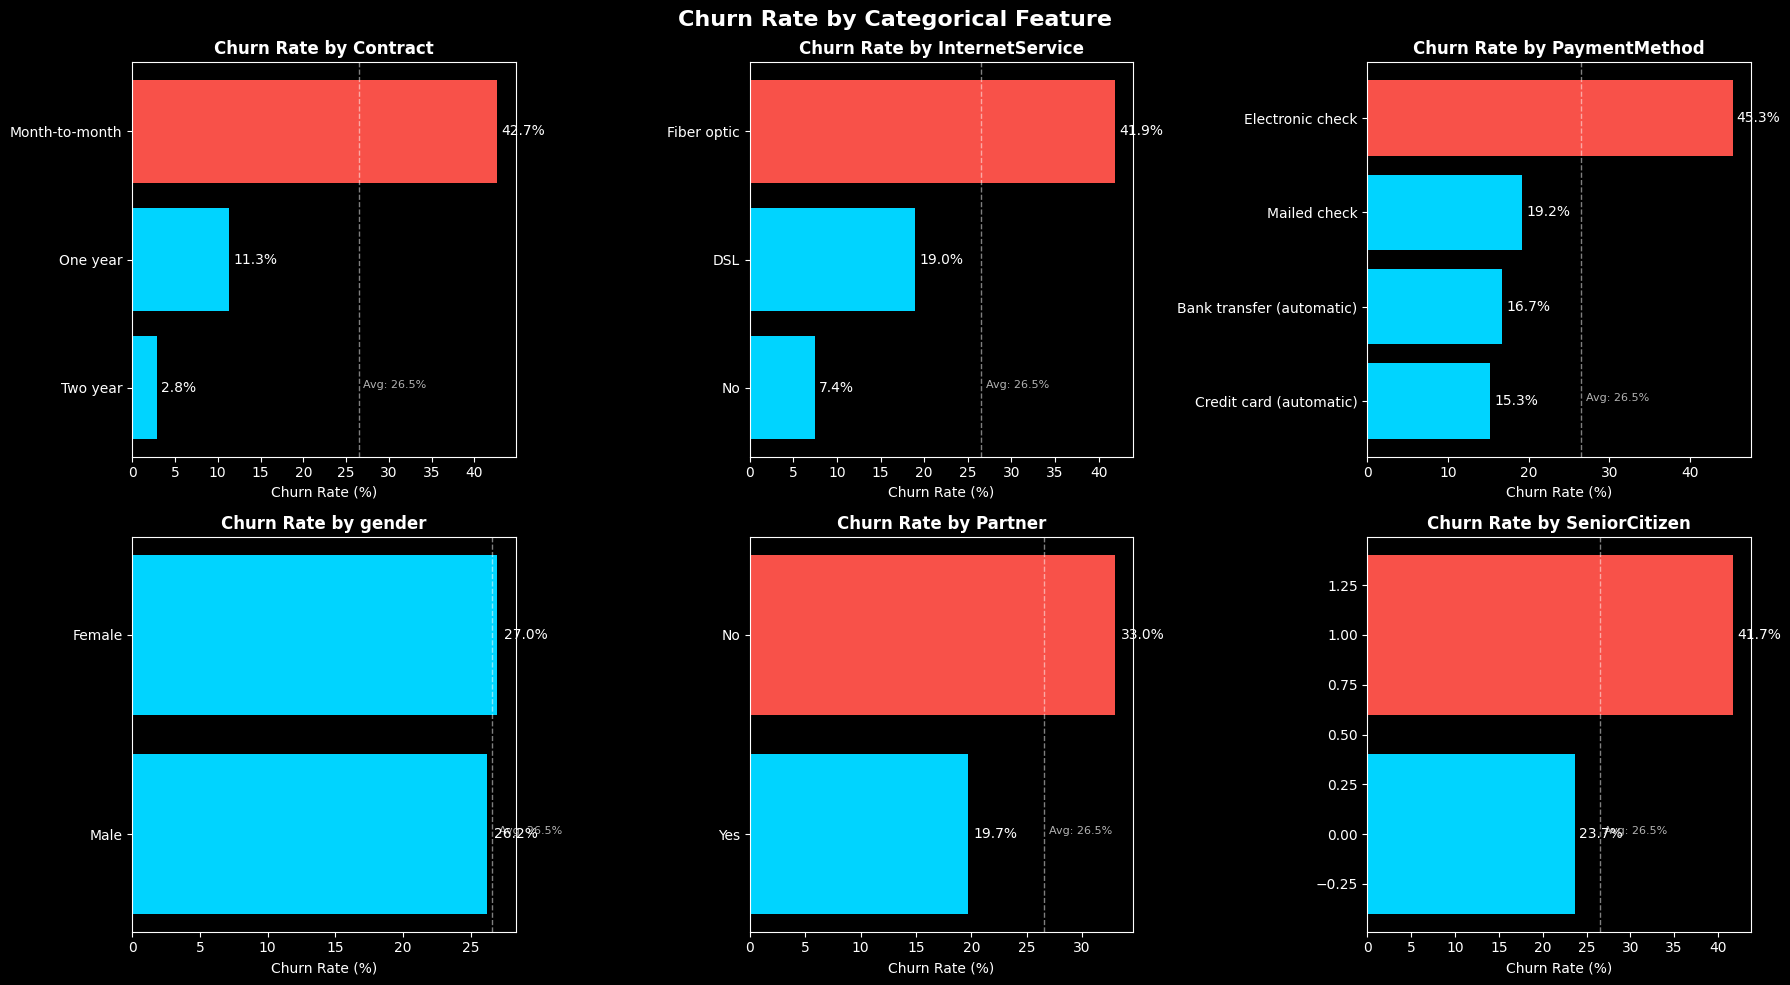


KEY INSIGHTS:
  Contract: Month-to-month customers churn at ~42% vs ~3% for 2-year contracts!
  Internet: Fiber optic users churn more — possibly due to higher prices
  Payment : Electronic check users have the highest churn rate
  Senior  : Senior citizens churn at a higher rate than non-seniors


In [ ]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'gender', 'Partner', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    churn_by_cat = df_eda.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=True)

    colors_bar = [COLORS['churn'] if v > 30 else COLORS['accent']
                  for v in churn_by_cat.values]

    bars = ax.barh(churn_by_cat.index, churn_by_cat.values, color=colors_bar)

    for bar, val in zip(bars, churn_by_cat.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.axvline(x=churn_rate, color='white', linestyle='--', alpha=0.5, linewidth=1)

    ax.text(churn_rate + 0.5, 0, f'Avg: {churn_rate:.1f}%', fontsize=8,
            color='white', alpha=0.7)

fig.suptitle('Churn Rate by Categorical Feature', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '04_categorical_churn_rates.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nKEY INSIGHTS:")
print("  Contract: Month-to-month customers churn at ~42% vs ~3% for 2-year contracts!")
print("  Internet: Fiber optic users churn more — possibly due to higher prices")
print("  Payment : Electronic check users have the highest churn rate")
print("  Senior  : Senior citizens churn at a higher rate than non-seniors")

 CORRELATION MATRIX


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn_binary
tenure,1.000,0.247,0.826,0.016,-0.354
MonthlyCharges,0.247,1.000,0.651,0.220,0.193
TotalCharges,0.826,0.651,1.000,0.102,-0.199
SeniorCitizen,0.016,0.220,0.102,1.000,0.151
Churn_binary,-0.354,0.193,-0.199,0.151,1.000



 CORRELATION WITH CHURN (most predictive features):
   tenure              : -0.354 (↓ negative)
   TotalCharges        : -0.199 (↓ negative)
   MonthlyCharges      : +0.193 (↑ positive)
   SeniorCitizen       : +0.151 (↑ positive)


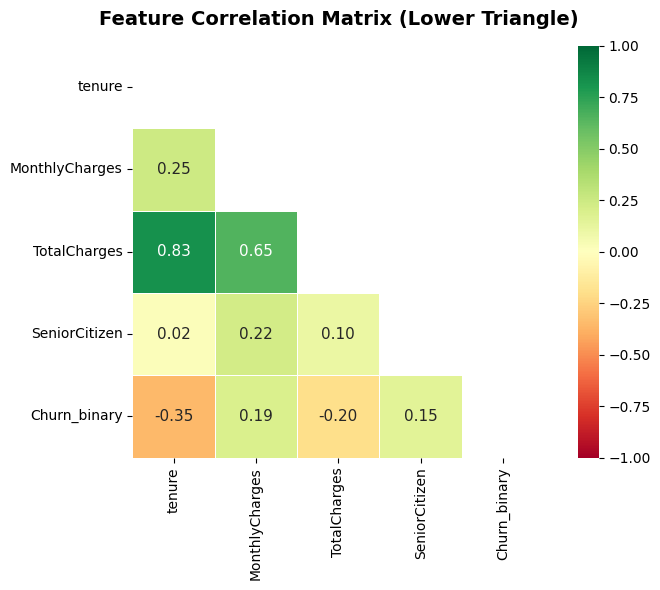


 KEY INSIGHTS:
  tenure vs TotalCharges: High positive correlation (0.83) — longer tenure = more total paid
  tenure vs Churn:        Negative — longer tenure customers churn less
  MonthlyCharges vs Churn: Positive — higher monthly bill → more likely to churn


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

df_raw = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_eda = df_raw.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda.dropna(subset=['TotalCharges'], inplace=True);

corr_df = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
corr_df['Churn_binary'] = (df_eda['Churn'] == 'Yes').astype(int);

corr_matrix = corr_df.corr();


print(" CORRELATION MATRIX")
display(corr_matrix.round(3));

print("\n CORRELATION WITH CHURN (most predictive features):")
churn_corr = corr_matrix['Churn_binary'].drop('Churn_binary').sort_values(key=abs, ascending=False);

for feat, corr_val in churn_corr.items():
    direction = '↑ positive' if corr_val > 0 else '↓ negative'
    print(f"   {feat:<20}: {corr_val:+.3f} ({direction})")

# ── Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6));

mask = np.triu(np.ones_like(corr_matrix, dtype=bool));

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True);
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '05_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHTS:")
print("  tenure vs TotalCharges: High positive correlation (0.83) — longer tenure = more total paid")
print("  tenure vs Churn:        Negative — longer tenure customers churn less")
print("  MonthlyCharges vs Churn: Positive — higher monthly bill → more likely to churn")

In [ ]:
import pandas as pd
df_raw = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

n_before = len(df)
df.dropna(subset=['TotalCharges'], inplace=True)
n_after = len(df) # Define n_after here

print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after  cleaning: {n_after:,}  (dropped {n_before - n_after} rows)")

# Drop customerID
df.drop(columns=['customerID'], inplace=True)

df.reset_index(drop=True, inplace=True)

print(f"\nCleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Rows before cleaning: 7,043
Rows after  cleaning: 7,032  (dropped 11 rows)

Cleaned dataset: 7,032 rows × 20 columns
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:

# Label Encoding (Binary Categorical Columns)

LABEL_ENCODE_COLS = [
    'gender',           # Male/Female → 0/1
    'Partner',          # Yes/No → 1/0
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn',            #  1/0  our TARGET column
]

label_encoders = {}

print("LABEL ENCODING")
for col in LABEL_ENCODE_COLS:
    if col not in df.columns:
        continue  # Skip if column doesn't exist (safety check)

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))
    # .fit_transform() does two things in one step
    # 1. fit() → learns the unique values and assigns numbers
    # 2. transform() → applies the learned mapping to the data
    # .astype(str) converts to string first to handle any edge cases.

    label_encoders[col] = le

    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    print(f"  {col:<20}: {mapping}")

print("\n Label encoding complete!")

LABEL ENCODING
  gender              : {'0': 0, '1': 1}
  Partner             : {'0': 0, '1': 1}
  Dependents          : {'0': 0, '1': 1}
  PhoneService        : {'0': 0, '1': 1}
  PaperlessBilling    : {'0': 0, '1': 1}
  Churn               : {'0': 0, '1': 1}

 Label encoding complete!


In [ ]:

OHE_COLS = [
    'MultipleLines',    # Yes/No/No phone service → 3 new columns
    'InternetService',  # DSL/Fiber optic/No → 3 new columns
    'OnlineSecurity',   # Yes/No/No internet service → 3 new columns
    'OnlineBackup',     # Yes/No/No internet service → 3 new columns
    'DeviceProtection', # Yes/No/No internet service → 3 new columns
    'TechSupport',      # Yes/No/No internet service → 3 new columns
    'StreamingTV',      # Yes/No/No internet service → 3 new columns
    'StreamingMovies',  # Yes/No/No internet service → 3 new columns
    'Contract',         # Month-to-month/One year/Two year → 3 new columns
    'PaymentMethod',    # 4 methods → 4 new columns
]

print("Columns BEFORE One-Hot Encoding:", df.shape[1])

df = pd.get_dummies(df, columns=OHE_COLS, drop_first=False)
# pd.get_dummies() is the simplest way to One-Hot Encode in Pandas.

print("Columns AFTER  One-Hot Encoding:", df.shape[1])
print(f"\nNew columns added: {df.shape[1] - 6}")
print("\nAll columns after encoding:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Columns BEFORE One-Hot Encoding: 20
Columns AFTER  One-Hot Encoding: 41

New columns added: 35

All columns after encoding:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. PaperlessBilling
   8. MonthlyCharges
   9. TotalCharges
  10. Churn
  11. MultipleLines_No
  12. MultipleLines_No phone service
  13. MultipleLines_Yes
  14. InternetService_DSL
  15. InternetService_Fiber optic
  16. InternetService_No
  17. OnlineSecurity_No
  18. OnlineSecurity_No internet service
  19. OnlineSecurity_Yes
  20. OnlineBackup_No
  21. OnlineBackup_No internet service
  22. OnlineBackup_Yes
  23. DeviceProtection_No
  24. DeviceProtection_No internet service
  25. DeviceProtection_Yes
  26. TechSupport_No
  27. TechSupport_No internet service
  28. TechSupport_Yes
  29. StreamingTV_No
  30. StreamingTV_No internet service
  31. StreamingTV_Yes
  32. StreamingMovies_No
  33. StreamingMovies_No internet service
  34. StreamingMovies_Yes
  35. Contr

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

TARGET = 'Churn'
X = df.drop(columns=[TARGET])

y = df[TARGET].values.astype(np.float32)

feature_names = list(X.columns)

print(f"Features (X): {X.shape}  → {X.shape[1]} features for {X.shape[0]:,} customers")
print(f"Target   (y): {y.shape}  → {y.sum():.0f} churners, {(1-y).sum():.0f} non-churners")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
  )

print(f"\nTraining set : {X_train.shape[0]:,} customers  (churn rate: {y_train.mean():.1%})")
print(f"Test set     : {X_test.shape[0]:,}  customers  (churn rate: {y_test.mean():.1%})")
print(f"\n Both sets have similar churn rate (stratify=y worked!)")

Features (X): (7032, 40)  → 40 features for 7,032 customers
Target   (y): (7032,)  → 1869 churners, 5163 non-churners

Training set : 5,625 customers  (churn rate: 26.6%)
Test set     : 1,407  customers  (churn rate: 26.6%)

 Both sets have similar churn rate (stratify=y worked!)


In [ ]:
from sklearn.preprocessing import StandardScaler

NUMERIC_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train_arr = X_train.values.copy().astype(np.float32)
X_test_arr  = X_test.values.copy().astype(np.float32)

num_idx = [list(X_train.columns).index(c) for c in NUMERIC_COLS]

X_train_arr[:, num_idx] = scaler.fit_transform(X_train_arr[:, num_idx])
# [:, num_idx] = all rows, only the numeric column positions.

X_test_arr[:, num_idx] = scaler.transform(X_test_arr[:, num_idx])

print(" SCALING VERIFICATION")
print(f"{'Column':<20} {'Before (mean/std)':<25} {'After (mean/std)'}")
for i, col in zip(num_idx, NUMERIC_COLS):
    raw_col = X_train.values[:, i]
    scaled_col = X_train_arr[:, i]
    print(f"{col:<20} {raw_col.mean():.1f} / {raw_col.std():.1f}{'':>10} → {scaled_col.mean():.4f} / {scaled_col.std():.4f}")

print(f"\n Numeric features now have mean≈0 and std≈1 — ready for neural network!")
print(f"Final shape: X_train={X_train_arr.shape}, X_test={X_test_arr.shape}")

 SCALING VERIFICATION
Column               Before (mean/std)         After (mean/std)
tenure               32.6 / 24.5           → 0.0000 / 1.0000
MonthlyCharges       65.0 / 30.1           → -0.0000 / 1.0000
TotalCharges         2301.8 / 2275.4           → 0.0000 / 1.0000

 Numeric features now have mean≈0 and std≈1 — ready for neural network!
Final shape: X_train=(5625, 40), X_test=(1407, 40)


In [ ]:
import os
import pickle

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(MODELS_DIR, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)


with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODELS_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)


print("Preprocessing artifacts saved to Google Drive:")
print(f"label_encoders.pkl → {len(label_encoders)} encoders")
print(f"scaler.pkl         → scaled {len(NUMERIC_COLS)} numeric columns")
print(f"feature_names.pkl  → {len(feature_names)} features")

for fname in ['label_encoders.pkl', 'scaler.pkl', 'feature_names.pkl']:
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path)  # file size in bytes
    print(f"  {fname}  ({size:,} bytes)")

Preprocessing artifacts saved to Google Drive:
label_encoders.pkl → 6 encoders
scaler.pkl         → scaled 3 numeric columns
feature_names.pkl  → 40 features
  label_encoders.pkl  (604 bytes)
  scaler.pkl  (522 bytes)
  feature_names.pkl  (947 bytes)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def build_model(input_dim: int) -> keras.Model:
    """
    Build and compile the ANN model.

    Args:
        input_dim: Number of input features (columns after preprocessing).

    Returns:
        Compiled Keras Model ready for training.
    """
    inputs = keras.Input(shape=(input_dim,), name='input_layer')

    # The comma after input_dim makes it a tuple: (30,) not (30).
    # name='input_layer' for readability in model summary.

    # ── Hidden Layer 1
    x = layers.Dense(
        64,

        activation='relu',


        kernel_regularizer=regularizers.l2(1e-4),

        name='hidden_1'
    )(inputs)


    x = layers.BatchNormalization(name='bn_1')(x)

    x = layers.Dropout(0.30, name='dropout_1')(x)

    #  Hidden Layer 2
    x = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='hidden_2'
    )(x)

    x = layers.BatchNormalization(name='bn_2')(x)

    x = layers.Dropout(0.20, name='dropout_2')(x)

    # Output Layer
    output = layers.Dense(
        1,

        activation='sigmoid',
        name='output_layer'
    )(x)


    model = keras.Model(inputs=inputs, outputs=output, name='TelcoChurnANN')
    # keras.Model() connects input→output to create the full model graph.

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),


        loss='binary_crossentropy',
        # Loss function measures how WRONG the model is.
        # Binary cross-entropy is the standard loss for binary classification

        metrics=[
            'accuracy',

            keras.metrics.AUC(name='auc'),

            keras.metrics.Precision(name='precision'),

            keras.metrics.Recall(name='recall'),
        ]
    )

    return model


input_dim = X_train_arr.shape[1]


model = build_model(input_dim)

print(" ANN ARCHITECTURE")
model.summary()

 ANN ARCHITECTURE


Model: "TelcoChurnANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weight_dict = {int(c): w for c, w in zip(classes, weights)}

print(" CLASS WEIGHTS (to handle imbalance):")
print(f"   Class 0 (No Churn) weight: {class_weight_dict[0]:.4f}")
print(f"   Class 1 (Churn)    weight: {class_weight_dict[1]:.4f}")
print(f"   → Churn mistakes cost {class_weight_dict[1]/class_weight_dict[0]:.1f}x more than No-Churn mistakes")


# WHY CALLBACKS
# Callbacks are functions that Keras calls at specific points during training.
# They let us add intelligent behaviour: stop early, reduce LR, save best model.

MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'ann_model.keras')

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor='val_loss',

        patience=12,

        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',

        factor=0.5,
        # Multiply the learning rate by 0.5 when triggered.
        patience=5,

        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        # For AUC, higher is better. mode='max' means:
        # 'save when this metric is at its maximum'.

        verbose=1
    ),
]

print(" Callbacks configured:")
print("  EarlyStopping     — patience=12 epochs, restores best weights")
print("   ReduceLROnPlateau — halves LR after 5 epochs of no improvement")
print("   ModelCheckpoint   — saves best model by val_AUC")

 CLASS WEIGHTS (to handle imbalance):
   Class 0 (No Churn) weight: 0.6810
   Class 1 (Churn)    weight: 1.8813
   → Churn mistakes cost 2.8x more than No-Churn mistakes
 Callbacks configured:
  EarlyStopping     — patience=12 epochs, restores best weights
   ReduceLROnPlateau — halves LR after 5 epochs of no improvement
   ModelCheckpoint   — saves best model by val_AUC


In [ ]:

val_size = int(len(X_train_arr) * 0.12)
# Use 12% of training data for internal validation (early stopping signal)

X_tr  = X_train_arr[val_size:]    # 88% of training data → actual training
X_val = X_train_arr[:val_size]    # 12% of training data → validation
y_tr  = y_train[val_size:]
y_val = y_train[:val_size]

print(f"Training samples  : {len(X_tr):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples      : {len(X_test_arr):,} (held out, not used during training)")
print(f"Input features    : {X_tr.shape[1]}")

history = model.fit(
    X_tr, y_tr,

    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    # Apply our configured callbacks.

    verbose=1
    # 1 = show a progress bar for each epoch.
    # 0 = silent, 2 = one line per epoch.
)

print(f"   Best val_auc: {max(history.history['val_auc']):.4f}")
print(f"   Epochs run  : {len(history.history['loss'])}")

Training samples  : 4,950
Validation samples: 675
Test samples      : 1,407 (held out, not used during training)
Input features    : 40
Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6429 - auc: 0.7272 - loss: 0.6849 - precision: 0.3999 - recall: 0.7365
Epoch 1: val_auc improved from None to 0.81767, saving model to models/ann_model.keras

Epoch 1: finished saving model to models/ann_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6828 - auc: 0.7726 - loss: 0.6239 - precision: 0.4454 - recall: 0.7648 - val_accuracy: 0.6519 - val_auc: 0.8177 - val_loss: 0.6503 - val_precision: 0.4148 - val_recall: 0.8728 - learning_rate: 0.0010
Epoch 2/100
144/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7124 - auc: 0.8099 - loss: 0.5616 - precision: 0.4829 - recall: 0.7756
Epoch 2: val_auc improved from 0.81767 to 0.82780, saving model to models/ann_model.keras

Epoch 2: finished saving model to models/ann_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/s

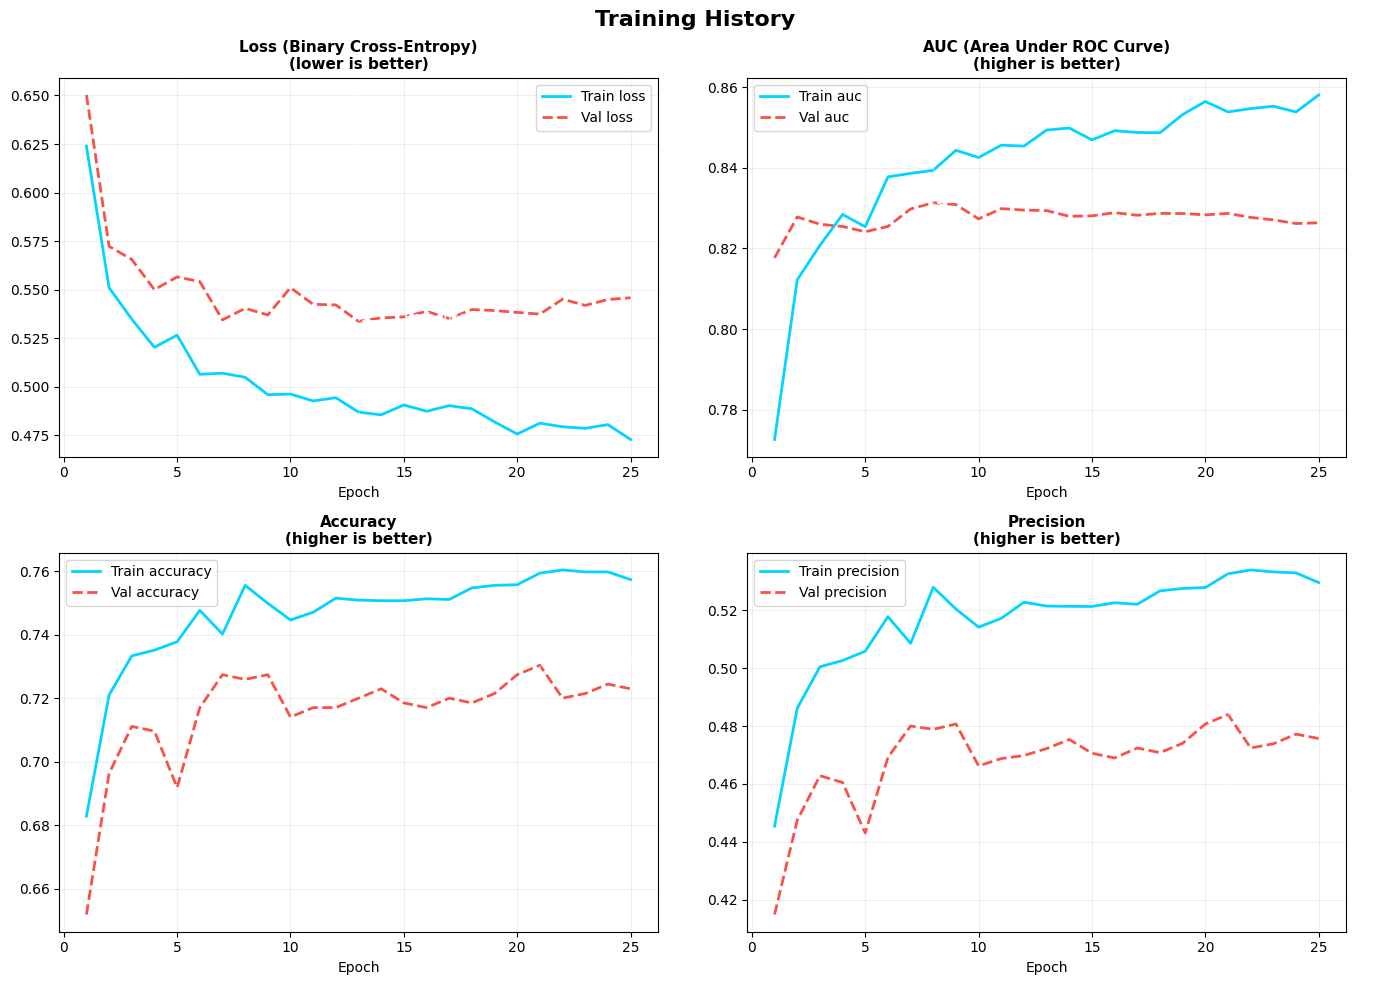

In [ ]:
import matplotlib.pyplot as plt
import os

COLORS = {
    'churn':    '#f85149',  # Red — danger/warning color for churn
    'no_churn': '#39d353',  # Green — safe/good color for no churn
    'accent':   '#00d4ff',  # Cyan — highlight/accent color
    'neutral':  '#7d8590',  # Grey — muted/secondary information
}

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('loss',      'Loss (Binary Cross-Entropy)', 'lower is better'),
    ('auc',       'AUC (Area Under ROC Curve)',  'higher is better'),
    ('accuracy',  'Accuracy',                    'higher is better'),
    ('precision', 'Precision',                   'higher is better'),
]

for ax, (metric, title, note) in zip(axes, metrics_to_plot):
    train_values = history.history[metric]
    val_values   = history.history[f'val_{metric}']
    epochs_range = range(1, len(train_values) + 1)

    ax.plot(epochs_range, train_values, label=f'Train {metric}',
            color=COLORS['accent'], linewidth=2)
    ax.plot(epochs_range, val_values, label=f'Val {metric}',
            color=COLORS['churn'], linewidth=2, linestyle='--')

    if 'loss' in metric:
        best_epoch = np.argmin(val_values)
        # For loss: best = minimum value. np.argmin returns the INDEX of minimum.
    else:
        best_epoch = np.argmax(val_values)
        # For other metrics: best = maximum value.

    ax.axvline(x=best_epoch + 1, color='white', linestyle=':', alpha=0.6, linewidth=1)
    ax.annotate(f'Best epoch: {best_epoch+1}',
                xy=(best_epoch + 1, val_values[best_epoch]),
                fontsize=9, color='white',
                xytext=(best_epoch + 3, val_values[best_epoch]),
                arrowprops=dict(arrowstyle='->', color='white'))

    ax.set_title(f'{title}\n({note})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.2)

fig.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '06_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

y_prob = model.predict(X_test_arr, verbose=0).flatten()
THRESHOLD = 0.50
# P(churn) >= 0.50 → predict 'Churn' (1)
# P(churn)  < 0.50 → predict 'No Churn' (0)

y_pred = (y_prob >= THRESHOLD).astype(int)

metrics_results = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, zero_division=0),
    'F1 Score' : f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob),
    # Area Under the ROC Curve.
    # ROC curve plots True Positive Rate vs False Positive Rate at all thresholds.
    # AUC = 0.5 → random guessing, AUC = 1.0 → perfect model.
    # Uses y_prob (not y_pred) because it evaluates across ALL thresholds.
    # AUC > 0.80 is generally considered good.
}

for metric, value in metrics_results.items():
    bar = '█' * int(value * 30)
    print(f"  {metric:<12}: {value:.4f}  {bar}")

print("\n FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  Accuracy    : 0.7242  █████████████████████
  Precision   : 0.4888  ██████████████
  Recall      : 0.8155  ████████████████████████
  F1 Score    : 0.6112  ██████████████████
  ROC-AUC     : 0.8340  █████████████████████████

 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1033
       Churn       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407



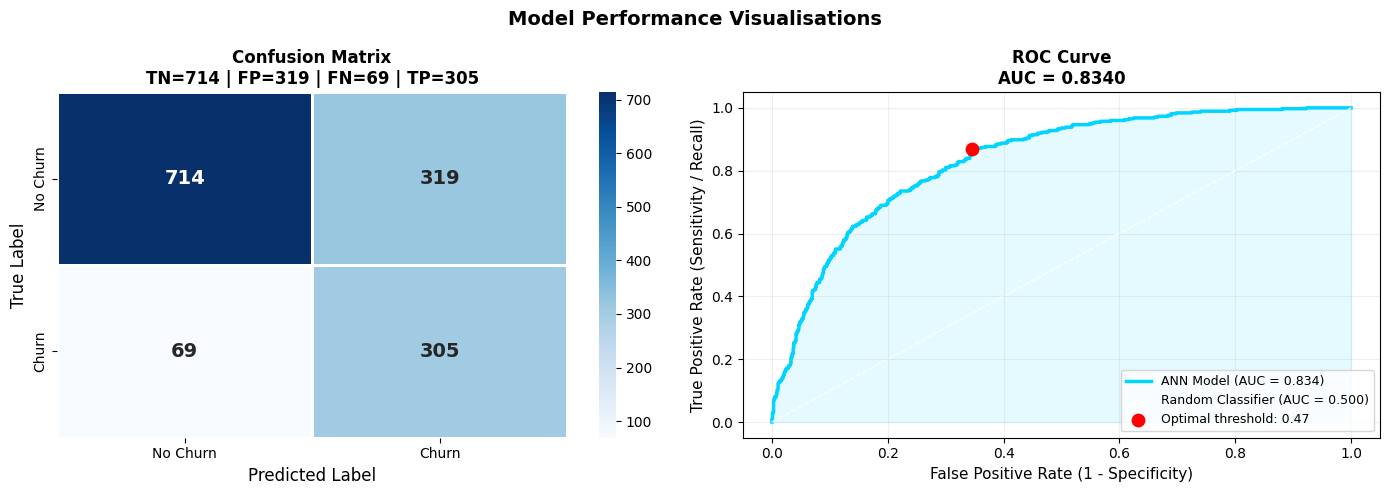


 Business Impact of Confusion Matrix:
   True Negatives (TN) =  714 → Correctly identified loyal customers 
   False Positives (FP)=  319 → Incorrectly flagged (unnecessary retention effort) 
   False Negatives (FN)=   69 → Missed churners (REVENUE LOST — most critical!) 
   True Positives (TP) =  305 → Correctly caught churners (retention opportunity!) 


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
# .ravel() flattens the 2D matrix to 1D: [TN, FP, FN, TP]

sns.heatmap(
    cm,
    annot=True,    # Show numbers inside each cell
    fmt='d',       # Format as integer (not scientific notation)
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=ax1,
    linewidths=1,
    annot_kws={'size': 14, 'fontweight': 'bold'}
)
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title(f'Confusion Matrix\nTN={tn} | FP={fp} | FN={fn} | TP={tp}',
              fontsize=12, fontweight='bold')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

ax2.plot(fpr, tpr, color=COLORS['accent'], linewidth=2.5,
         label=f'ANN Model (AUC = {auc_score:.3f})')
ax2.plot([0, 1], [0, 1], 'w--', linewidth=1, label='Random Classifier (AUC = 0.500)')

optimal_idx = np.argmax(tpr - fpr)
ax2.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=80, zorder=5,
            label=f'Optimal threshold: {thresholds[optimal_idx]:.2f}')

ax2.fill_between(fpr, tpr, alpha=0.1, color=COLORS['accent'])

ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax2.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax2.set_title(f'ROC Curve\nAUC = {auc_score:.4f}', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.2)

fig.suptitle('Model Performance Visualisations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '07_confusion_matrix_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Business Impact of Confusion Matrix:")
print(f"   True Negatives (TN) = {tn:4d} → Correctly identified loyal customers ")
print(f"   False Positives (FP)= {fp:4d} → Incorrectly flagged (unnecessary retention effort) ")
print(f"   False Negatives (FN)= {fn:4d} → Missed churners (REVENUE LOST — most critical!) ")
print(f"   True Positives (TP) = {tp:4d} → Correctly caught churners (retention opportunity!) ")

In [ ]:


model.save(MODEL_SAVE_PATH)

if os.path.exists(MODEL_SAVE_PATH):
    size_mb = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024
    print(f" Model saved successfully!")
    print(f"    Path: {MODEL_SAVE_PATH}")
    print(f"   Size: {size_mb:.2f} MB")


print("\nFiles in models directory:")
for fname in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, fname)
    fsize = os.path.getsize(fpath) / 1024  # KB
    print(f"   {fname:<35} {fsize:,.1f} KB")

 Model saved successfully!
    Path: models/ann_model.keras
   Size: 0.10 MB

Files in models directory:
   scaler.pkl                          0.5 KB
   feature_names.pkl                   0.9 KB
   label_encoders.pkl                  0.6 KB
   ann_model.keras                     103.2 KB
